<a href="https://colab.research.google.com/github/utkarsha-a/AQI-Prediction-Model/blob/main/03_faster_r_cnn_for_roi_dectection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import cv2
import torch
import torchvision
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


In [ ]:
BASE_DIR = "/content/drive/MyDrive/ROI_Endoscopy_Paper/annotations"
IMG_DIR = os.path.join(BASE_DIR, "images")
XML_DIR = os.path.join(BASE_DIR, "xml")

In [ ]:
CLASSES = {
    "polyp": 1,
    "lesion": 2,
    "inflammation": 3
}
NUM_CLASSES = len(CLASSES) + 1  # + background

In [ ]:
def parse_voc_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    boxes = []
    labels = []

    for obj in root.findall("object"):
        label = obj.find("name").text.strip()

        if label not in CLASSES:
            continue

        bndbox = obj.find("bndbox")

        xmin = int(float(bndbox.find("xmin").text))
        ymin = int(float(bndbox.find("ymin").text))
        xmax = int(float(bndbox.find("xmax").text))
        ymax = int(float(bndbox.find("ymax").text))

        boxes.append([xmin, ymin, xmax, ymax])
        labels.append(CLASSES[label])

    if len(boxes) == 0:
        return None, None

    return torch.tensor(boxes, dtype=torch.float32), torch.tensor(labels)

In [ ]:
class EndoscopyROIDataset(torch.utils.data.Dataset):
    def __init__(self, img_dir, xml_dir):
        self.img_dir = img_dir
        self.xml_dir = xml_dir
        self.images = sorted(os.listdir(img_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)
        xml_path = os.path.join(self.xml_dir, img_name.replace(".jpg", ".xml"))

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = torch.tensor(img / 255.0, dtype=torch.float32).permute(2, 0, 1)

        boxes, labels = parse_voc_xml(xml_path)

        if boxes is None:
            return None

        target = {
            "boxes": boxes,
            "labels": labels
        }

        return img, target

In [ ]:
dataset = EndoscopyROIDataset(IMG_DIR, XML_DIR)

valid = 0
skipped = 0

for i in range(len(dataset)):
    sample = dataset[i]
    if sample is None:
        skipped += 1
    else:
        valid += 1

print("Valid ROI images:", valid)
print("Skipped (normal/no ROI):", skipped)

Valid ROI images: 70
Skipped (normal/no ROI): 169


In [ ]:
filtered_dataset = [d for d in dataset if d is not None]

In [ ]:
from torch.utils.data import random_split

train_size = int(0.8 * len(filtered_dataset))
val_size = len(filtered_dataset) - train_size

train_dataset, val_dataset = random_split(
    filtered_dataset, [train_size, val_size]
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Train samples: 56
Validation samples: 14


In [ ]:
def collate_fn(batch):
    return tuple(zip(*batch))


In [ ]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=collate_fn
)

In [ ]:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights="DEFAULT"
)

in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features,
    NUM_CLASSES
)

In [ ]:
model.to(DEVICE)


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [ ]:
NUM_EPOCHS = 10
loss_history = []

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0

    for images, targets in train_loader:
        images = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Loss: {avg_loss:.4f}")

Epoch [1/10] Loss: 0.3566
Epoch [2/10] Loss: 0.2793
Epoch [3/10] Loss: 0.2714
Epoch [4/10] Loss: 0.2637
Epoch [5/10] Loss: 0.2559
Epoch [6/10] Loss: 0.2325
Epoch [7/10] Loss: 0.2302
Epoch [8/10] Loss: 0.2261
Epoch [9/10] Loss: 0.2079
Epoch [10/10] Loss: 0.1952


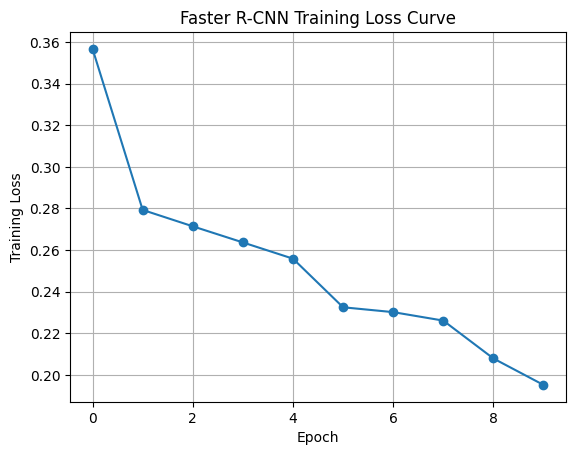

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Faster R-CNN Training Loss Curve")
plt.grid(True)
plt.show()

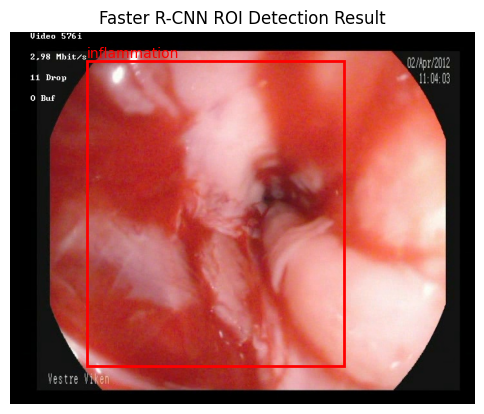

In [ ]:
model.eval()

img, _ = val_dataset[0]

with torch.no_grad():
    prediction = model([img.to(DEVICE)])[0]

img_np = img.permute(1, 2, 0).cpu().numpy()

plt.figure(figsize=(6,6))
plt.imshow(img_np)

for box, label, score in zip(
    prediction["boxes"],
    prediction["labels"],
    prediction["scores"]
):
    if score > 0.5:
        xmin, ymin, xmax, ymax = box.int().tolist()
        class_name = [k for k,v in CLASSES.items() if v == label.item()][0]
        plt.gca().add_patch(
            plt.Rectangle(
                (xmin, ymin),
                xmax-xmin,
                ymax-ymin,
                fill=False,
                edgecolor='red',
                linewidth=2
            )
        )
        plt.text(xmin, ymin-5, class_name, color='red')

plt.axis("off")
plt.title("Faster R-CNN ROI Detection Result")
plt.show()

A Faster R-CNN model with a ResNet-50 backbone pretrained on COCO was fine-tuned on annotated endoscopy frames to localize regions of interest including polyps, lesions, and inflammatory regions.

In [ ]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/ROI_Endoscopy_Paper/faster_rcnn_roi.pth"
)